In [147]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



In [202]:

# --- INIT ---



# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
mesor_frac_thresh = 0.9
mesor_effect_thresh = 0.3 / np.log10(np.e)
amp_frac_thresh = 0.9
amp_effect_thresh = 0.2 / np.log10(np.e)
acrophase_frac_thresh = 0.1
acrophase_effect_thresh = 3 * (np.pi / 12.0)
frac_circadian_samples_crossing_zero_thresh = 0.1
log10_bf_thresh = 2
num_waveform_samples = 300
use_log_prop_fft = True
frac_cell_detected_thresh = 0.1
use_subclusters = False

# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_4_male_aligned_vs_male_misaligned' % head_folder
if use_subclusters:
    folder_out = '%s/smc_subclusters' % folder_out
if not os.path.exists(folder_out):
    os.makedirs(folder_out)


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [203]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [204]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [205]:
# --- GET UNIQUE DESCRIPTOINS / CELL TYPES AND SET THE CLUSTER - CELL_TYPE DICT ---

# ** get the unique descriptions **
descriptions = list(adata.obs['description'].unique())

# ** get the unique clusters **
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(clusters)


# ** get the cluster cell type dict **
if use_subclusters:
    smc_subcluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
    cluster_cell_type_dict = dict(zip(clusters,
                                      smc_subcluster_cell_type_names))
else:
    cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                      ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial2', 'Neuron']))


    


In [206]:
# --- LIMIT CLUSTERS ---

if use_subclusters:
    clusters = [0,1,2,3,4,5]
else:
    clusters = [0,1,2,3]
    
clusters
    

[0, 1, 2, 3]

In [207]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [208]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)




22193

In [209]:
# --- SET THE CLUSTER ----


cluster = 0


In [210]:
# --- SET THE CONDITIONS WE WANT TO COMPARE ---

condit_1 = 'male aligned bmal1-control'
condit_2 = 'male misaligned bmal1-control'
condit_1_label = 'Aligned'
condit_2_label = 'Misaligned'
dif_label = 'Alignment'




In [211]:
# --- LOAD THE PARAMS ---


# init param dict
param_df_dict = {}

# fill
for sex in ['male', 'female']:
    if sex not in param_df_dict:
        param_df_dict[sex] = {}
    for alignment in ['aligned', 'misaligned']:
        condit = '%s %s bmal1-control' % (sex, alignment)
        gene_log_alpha_df_1, gene_log_beta_df_1, gene_log_min_max_df_1, gene_stat_df_1 = helper_functions.load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit])
        param_df_dict[sex][alignment] = {
            "log_alpha_df" : gene_log_alpha_df_1,
            'log_beta_df' : gene_log_beta_df_1,
            'log_min_max_df' : gene_log_min_max_df_1,
            'gene_stat_df' : gene_stat_df_1
        }










In [212]:
# --- FILTER GENES BASED ON DETECTED FRACTION ---


# set frac detected thresh
frac_cell_detected_thresh = 0.1

# clock and ubiq genes
clock_and_ubiq_path = '%s/Desktop/tempo/data/core_clock_and_ubiq_genes.txt' % head_folder
clock_and_ubiq_genes = np.array(pd.read_table(clock_and_ubiq_path,header=None).iloc[:,0])

# hemoglobin genes
hemoglobin_genes = list(filter(lambda x: x[:2] == 'Hb' and '-' in x, adata.var_names))

# genes to filter
genes_to_filter = set()
print("Using the union of genes to filter over the conditions.\nNeed to implement intersection too.")
for sex in ['male', 'female']:
    for alignment in ['aligned', 'misaligned']:
        gene_stat_df = param_df_dict[sex][alignment]['gene_stat_df']
        these_genes_to_filter = list(gene_stat_df[np.array(gene_stat_df['frac_cell_detected'] < frac_cell_detected_thresh) & np.array(~np.isin(gene_stat_df.index,clock_and_ubiq_genes))].index)
        genes_to_filter.update(set(these_genes_to_filter))
genes_to_filter = list(set(genes_to_filter).union(set(hemoglobin_genes)))
print("%s genes filtered" % len(genes_to_filter))

# get common genes
common_genes = set()
df_num = 0
for sex in ['male', 'female']:
    for alignment in ['aligned', 'misaligned']:
        gene_stat_df = param_df_dict[sex][alignment]['gene_stat_df']
        if df_num == 0:
            common_genes = set(gene_stat_df.index)
        else:
            common_genes = common_genes.intersection(set(gene_stat_df.index))
        df_num += 1
common_genes = list(common_genes.difference(set(genes_to_filter)))
print("%s common genes to compare" % len(common_genes))

# filter
for sex in ['male', 'female']:
    for alignment in ['aligned', 'misaligned']:
        for df in param_df_dict[sex][alignment]:
            param_df_dict[sex][alignment][df] = param_df_dict[sex][alignment][df].loc[common_genes]


            
            


Using the union of genes to filter over the conditions.
Need to implement intersection too.
12829 genes filtered
8323 common genes to compare


In [213]:
# --- GET THE COMMON CYCLING GENES ----


# fill
common_cyclers = set()
df_count = 0
for sex in ['male', 'female']:
    for alignment in ['aligned', 'misaligned']:
        
        # get cyclers for the condition
        condit_cyclers = param_df_dict[sex][alignment]['gene_stat_df'][param_df_dict[sex][alignment]['gene_stat_df']['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh].index
        condit_cyclers = list(condit_cyclers)
        print("%s %s %s cyclers" % (sex, alignment, len(condit_cyclers)))
        
        # add
        if df_count == 0:
            common_cyclers = set(condit_cyclers)
        else:
            common_cyclers = common_cyclers.intersection(set(condit_cyclers))
        
        # increment df count
        df_count += 1
common_cyclers = list(common_cyclers)

print("%s common cyclers" % len(common_cyclers))
        
        



male aligned 707 cyclers
male misaligned 438 cyclers
female aligned 844 cyclers
female misaligned 556 cyclers
150 common cyclers


In [214]:
# --- LIMIT THE DF'S TO THE COMMON CYCLERS ---

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# filter
for sex in ['male', 'female']:
    for alignment in ['aligned', 'misaligned']:
        for df in param_df_dict[sex][alignment]:
            param_df_dict[sex][alignment][df] = param_df_dict[sex][alignment][df].loc[common_cyclers]





In [215]:
# --- GET TENSOR DICT ---

# init param dict
param_dict = {}

# fill
for sex in ['male', 'female']:
    if sex not in param_dict:
        param_dict[sex] = {}
    for alignment in ['aligned', 'misaligned']:
        gene_log_min_1 = torch.Tensor(np.array(param_df_dict[sex][alignment]['log_min_max_df']['log_min'])) 
        gene_log_max_1 = torch.Tensor(np.array(param_df_dict[sex][alignment]['log_min_max_df']['log_max']))
        gene_log_alpha_1 = torch.Tensor(np.array(param_df_dict[sex][alignment]['log_alpha_df']).T)
        gene_log_beta_1 = torch.Tensor(np.array(param_df_dict[sex][alignment]['log_beta_df']).T)

        param_dict[sex][alignment] = {
            'log_alpha' : gene_log_alpha_1,
            'log_beta' : gene_log_beta_1,
            'log_min' : gene_log_min_1,
            'log_max' : gene_log_max_1
        }
        
        

        
        




In [216]:
# --- GET SAMPLED WAVEFORM DICT  ---


# init waveform dict
sampled_waveform_dict = {}

# fill
for sex in ['male', 'female']:
    if sex not in sampled_waveform_dict:
        sampled_waveform_dict[sex] = {}
    for alignment in ['aligned', 'misaligned']:
        

        # get the log_prop_dist obj
        log_prop_dist = torch.distributions.beta.Beta(torch.exp(param_dict[sex][alignment]['log_alpha']), torch.exp(param_dict[sex][alignment]['log_beta']))

        # sample the waveforms
        sampled_log_prop = log_prop_dist.sample((num_waveform_samples,)) # [num_samples x num_time_points x num_genes]
        sampled_log_prop = (sampled_log_prop * (param_dict[sex][alignment]['log_max'].unsqueeze(0).unsqueeze(0) - param_dict[sex][alignment]['log_min'].unsqueeze(0).unsqueeze(0))) + param_dict[sex][alignment]['log_min'].unsqueeze(0).unsqueeze(0)
        sampled_waveform_dict[sex][alignment] = sampled_log_prop

        print(sampled_log_prop.shape)
        





torch.Size([300, 4, 150])
torch.Size([300, 4, 150])
torch.Size([300, 4, 150])
torch.Size([300, 4, 150])


In [217]:
# --- GET ACROPHASE SAMPLE DICT ---


# init acrophase dict
sampled_acrophase_dict = {}

# fill
for sex in ['male', 'female']:
    if sex not in sampled_acrophase_dict:
        sampled_acrophase_dict[sex] = {}
    for alignment in ['aligned', 'misaligned']:
        
        # get sampled fft
        sampled_waveform = sampled_waveform_dict[sex][alignment]
        num_grid_points = sampled_waveform.shape[1]
        sampled_fft = np.fft.fft(sampled_waveform,axis=1)
        
        # get circadian index for FFT's
        freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
        periods = 1 / freqs
        circadian_index = np.where(np.isin(periods,[24]))[0][0]
        
        # get sampled acrophase
        sampled_acrophase = (np.arctan2(sampled_fft[:,circadian_index,:].imag,sampled_fft[:,circadian_index,:].real) % (2 * np.pi))
        sampled_acrophase = ((2 * np.pi) - sampled_acrophase) % (2 * np.pi)
        sampled_acrophase_dict[sex][alignment] = sampled_acrophase
            

        
        




/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_93044/2996513075.py:20: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs


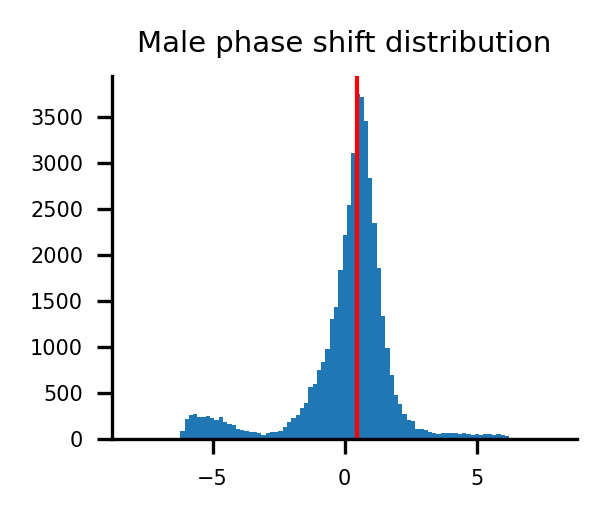

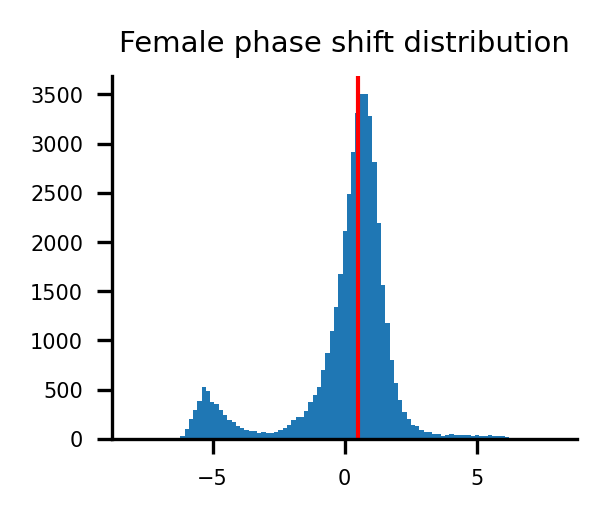

In [224]:
# --- SHOW THE PHASE SHIFT DISTRIBUTIONS ---

# male
m_dif_acrophase_samples = sampled_acrophase_dict['male']['misaligned'] - sampled_acrophase_dict['male']['aligned']
fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
plt.hist(m_dif_acrophase_samples.flatten(),bins=np.linspace(-8,8,100))
sns.despine()
plt.title("Male phase shift distribution")
plt.axvline(x = np.median(m_dif_acrophase_samples.flatten()),c='r')
plt.show()


# female
f_dif_acrophase_samples = sampled_acrophase_dict['female']['misaligned'] - sampled_acrophase_dict['female']['aligned']
fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
plt.hist(f_dif_acrophase_samples.flatten(),bins=np.linspace(-8,8,100))
sns.despine()
plt.title("Female phase shift distribution")
plt.axvline(x = np.median(f_dif_acrophase_samples.flatten()),c='r')
plt.show()




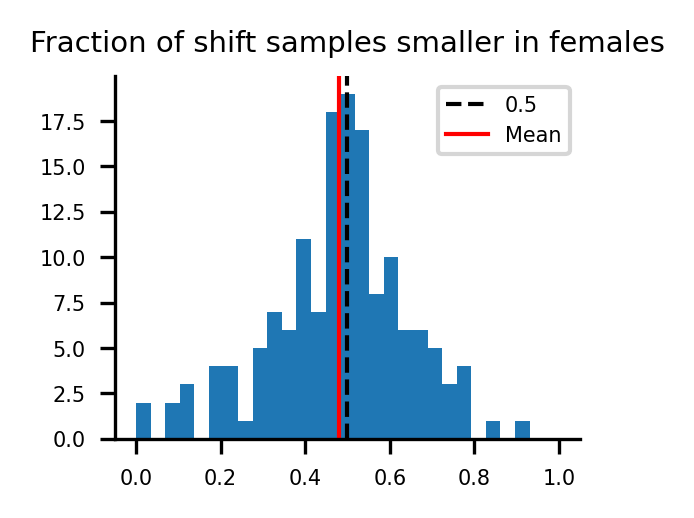

In [219]:
# --- FOR EACH GENE, COMPUTE THE FRACTION OF SAMPLED ACROPHASE DIF'S WHERE IT WAS SMALLER IN FEMALES ---


# male
m_dif_acrophase_samples = sampled_acrophase_dict['male']['misaligned'] - sampled_acrophase_dict['male']['aligned']
m_dif_acrophase_samples = np.abs(m_dif_acrophase_samples)

# female
f_dif_acrophase_samples = sampled_acrophase_dict['female']['misaligned'] - sampled_acrophase_dict['female']['aligned']
f_dif_acrophase_samples = np.abs(f_dif_acrophase_samples)

# get the fraction shifts smaller in females
frac_shifts_smaller = np.mean((f_dif_acrophase_samples < m_dif_acrophase_samples),axis=0)

# viz
fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
plt.hist(frac_shifts_smaller,bins=np.linspace(0,1,30))
sns.despine()
plt.title("Fraction of shift samples smaller in females")
plt.axvline(x = 0.5, c = 'k', linestyle = '--', label = '0.5')
plt.axvline(x = np.mean(frac_shifts_smaller), c = 'r', label='Mean')
plt.legend()
folder_out = '%s/Dropbox/aorta_circadian_data/results/phase_shift_sensitivity/use_smc_subclusters_%s/%s' % (head_folder,use_subclusters,cluster)
if not os.path.exists(folder_out):
    os.makedirs(folder_out)
fileout = '%s/plot.pdf' % folder_out
plt.savefig(fileout,bbox_inches='tight')
fileout = '%s/source_data.tsv' % folder_out
plt.show()

# write source data
frac_smaller_df = pd.DataFrame()
frac_smaller_df['gene'] = common_cyclers 
frac_smaller_df['frac_smaller'] = frac_shifts_smaller
frac_smaller_df = frac_smaller_df.sort_values(['gene'])
frac_smaller_df = frac_smaller_df.set_index('gene')
frac_smaller_df.to_csv(fileout,sep='\t')



